In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Defining Functions

In [44]:
# function to get the basic info about the dataset
def visual_data(df, hist_plot=True, corr_plot=True, multicollinear=True, corr_threshold=0.80):
    # basic info
    print("Data Information:")
    df.info()
    
    # first 10 rows
    print("\nFirst 10 rows:")
    print(df[:10])
    
    # duplicates
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    print(f"\nDuplicate Rows: {duplicate_count} ({duplicate_percentage:.2f}% of total rows)")

    # missing values
    missing_percentage = (df.isna().mean() * 100).round(2)
    total_missing = missing_percentage.sum()
    if total_missing > 0:
        print("\nMissing Values (%):")
        print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))
    else:
        print(f"\nMissing Values: 0.00%")
    
    # descriptive statistics for numeric columns
    print("\nDescriptive Statistics (Numerical):")
    print(df.describe().T.round(2))

    # descriptive statistics for categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'category'])
    print("\nDescriptive Statistics (Categorical):")
    print(categorical_cols.describe().T)

    # histogram
    if hist_plot:
        df.hist(bins=20, color='blue', edgecolor='black', 
        grid=False,figsize=(12, 8))
        plt.tight_layout()
        plt.show()
    
    # correlation heatmap
    if corr_plot:
        numeric_cols = df.select_dtypes(include=['number'])
        plt.figure(figsize=(8, 6))
        corr_matrix = numeric_cols.corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
        fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

    # multicollinearity
    if multicollinear and not numeric_cols.empty:
        print("\nChecking for Multicollinearity (Correlation Threshold > {:.2f}):".format(corr_threshold))
        high_corr_pairs = []
        corr_matrix = numeric_cols.corr().abs()  # Calculate correlation matrix for numeric columns only
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > corr_threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if high_corr_pairs:
            print("High correlation pairs found:")
            for pair in high_corr_pairs:
                print(f" - {pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")
        else:
            print("No highly correlated pairs found.")

    return df

In [45]:
# function that defines who appears before and after Hume's Warbler (target specie) within 3 seconds window
def birds_around(df, name="hume's warbler", window=3):
    events = df[df['Common name'] == name]
    output_rows = []
    
    for _, event in events.iterrows():
        # Define the time window masks for "before" and "after"
        before_mask = (
            (df['End (s)'] >= event['Start (s)'] - window) &
            (df['Start (s)'] <= event['Start (s)'])
        )
        after_mask = (
            (df['Start (s)'] >= event['End (s)']) &
            (df['Start (s)'] <= event['End (s)'] + window)
        )
        
        # Process birds before the event
        birds_before = df[before_mask]
        for _, bird in birds_before.iterrows():
            row = bird.to_dict()
            row.update({
                'Event_Start': event['Start (s)'],
                'Event_End': event['End (s)'],
                'Window': 'Before'
            })
            output_rows.append(row)
        
        # Process birds after the event
        birds_after = df[after_mask]
        for _, bird in birds_after.iterrows():
            row = bird.to_dict()
            row.update({
                'Event_Start': event['Start (s)'],
                'Event_End': event['End (s)'],
                'Window': 'After'
            })
            output_rows.append(row)
    
    result_df = pd.DataFrame(output_rows).drop_duplicates().reset_index(drop=True)
    return result_df


In [46]:
# merging cocontiguous intervals for rows with the same 'Scientific/Common name'
def merge_contiguous_intervals(df): # continuos 

    merged_rows = []
    
    # Start with the first row as the current interval
    current = df.iloc[0].copy()
    
    # Iterate over the DataFrame from the second row onward
    for idx in range(1, len(df)):
        row = df.iloc[idx]
        
        # If the same species and the intervals are contiguous, merge them
        if (row['Common name'] == current['Common name'] and 
            row['Start (s)'] == current['End (s)']):
            # Extend the current interval's end time
            current['End (s)'] = row['End (s)']
        else:
            merged_rows.append(current)
            current = row.copy()
    

    merged_rows.append(current)
    
    merged_df = pd.DataFrame(merged_rows)
    
    # Remove rows with a 3-second interval (i.e., where duration equals 3 seconds)
    merged_df = merged_df[(merged_df['End (s)'] - merged_df['Start (s)']) != 3]
    
    merged_df = merged_df.reset_index(drop=True)
    merged_df['Duration (s)'] = merged_df['End (s)'] - merged_df['Start (s)']
    return merged_df




In [47]:
# function to explore the dataset
# This function prints out unique values and their counts шт % for each column in the DataFrame.
def explore_dataset(df):
    for column in df.columns:
        print(f"Column: {column}")
        print("Unique values:")
        print(df[column].unique())
        print("\nValue counts:")
        print(round(df[column].value_counts(normalize=True) * 100, 2))
        print("-" * 40)

In [48]:
# function to calculate the accuracy of the dataset by calculating the mean confidence score
def accuracy(data):
    accuracy = data['Confidence'].mean().round(3)
    accuracy_habitant = data[data['Habitant'] == 1]['Confidence'].mean().round(3)
    accuracy__non_habitant = data[data['Habitant'] == 0]['Confidence'].mean().round(3)

    print('Total accuracy:' , accuracy)
    print('Habitant accuracy:' , accuracy_habitant)
    print('Non Habitant accuracy:' , accuracy__non_habitant)
    print('_ ' *40)

In [49]:
# function to filter the dataset by groups
# based on the combination of 'ID', 'Month', 'Day', and 'Time', 'Start' and 'End' columns  
def filter_dataset_by_groups(df):
    # Create the temporary column 'Temp_ID' by concatenating the 6 columns as strings
    df['Temp_ID'] = (
        df['ID'].astype(str) + '_' +
        df['Month'].astype(str) + '_' +
        df['Day'].astype(str) + '_' +
        df['Time'].astype(str) + '_' +
        df['Start (s)'].astype(str) + '_' +
        df['End (s)'].astype(str)
    )
    
    # Filter the dataframe to include only groups with more than one row.
    # This will drop rows that are the only instance in their group.
    filtered_df = df.groupby('Temp_ID').filter(lambda group: len(group) > 1).reset_index(drop=True)
    
    return filtered_df

Preprocessing Data

In [50]:
data = pd.read_csv('data/data_20250330.csv')

In [51]:
# dropping redundant columns
data = data.drop(columns=['Unnamed: 0', 'Scientific name', 'Year'])

# grouping the dataset into different subsets
data_05 = data
data_06 = data[data['Confidence'] >= 0.6]
data_07 = data[data['Confidence'] >= 0.7]
data_08 = data[data['Confidence'] >= 0.8]
data_09 = data[data['Confidence'] >= 0.9]

In [52]:
print('data_05')
accuracy(data_05)
print('data_06')
accuracy(data_06)
print('data_07')
accuracy(data_07)
print('data_08')
accuracy(data_08)
print('data_09')
accuracy(data_09)


data_05
Total accuracy: 0.754
Habitant accuracy: 0.769
Non Habitant accuracy: 0.673
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_06
Total accuracy: 0.813
Habitant accuracy: 0.823
Non Habitant accuracy: 0.748
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_07
Total accuracy: 0.865
Habitant accuracy: 0.871
Non Habitant accuracy: 0.815
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_08
Total accuracy: 0.912
Habitant accuracy: 0.915
Non Habitant accuracy: 0.879
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_09
Total accuracy: 0.957
Habitant accuracy: 0.957
Non Habitant accuracy: 0.94
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


Plot Total, Habitant and Non Habitant observations by confidence levels

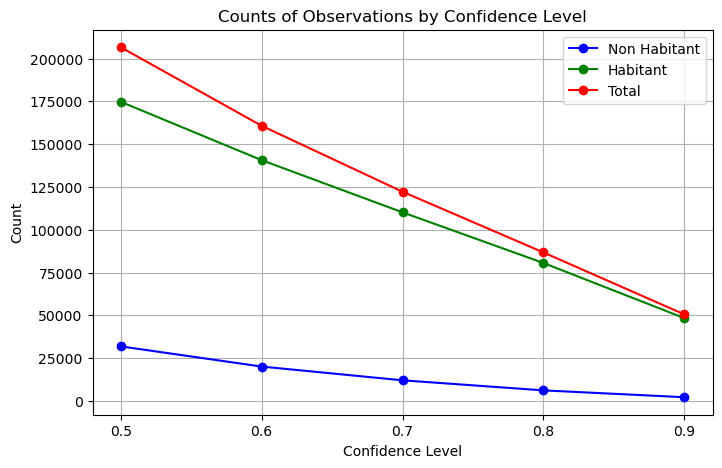

In [53]:
# Define confidence levels and corresponding datasets
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_0 = [x['Habitant'].value_counts().get(0, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
counts_1 = [x['Habitant'].value_counts().get(1, 0) for x in [data_05, data_06, data_07, data_08, data_09]]

# Compute total observations counts for each dataset
total_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Define x-axis positions
x = range(len(datasets))

plt.figure(figsize=(8, 5))
plt.plot(x, counts_0, marker='o', linestyle='-', color = 'blue', label='Non Habitant')
plt.plot(x, counts_1, marker='o', linestyle='-', color = 'green', label='Habitant')
plt.plot(x, total_counts, marker='o', linestyle='-', color = 'red', label='Total')

plt.xticks(x, datasets)
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.title("Counts of Observations by Confidence Level")
plt.legend()
plt.grid(True)
plt.show()


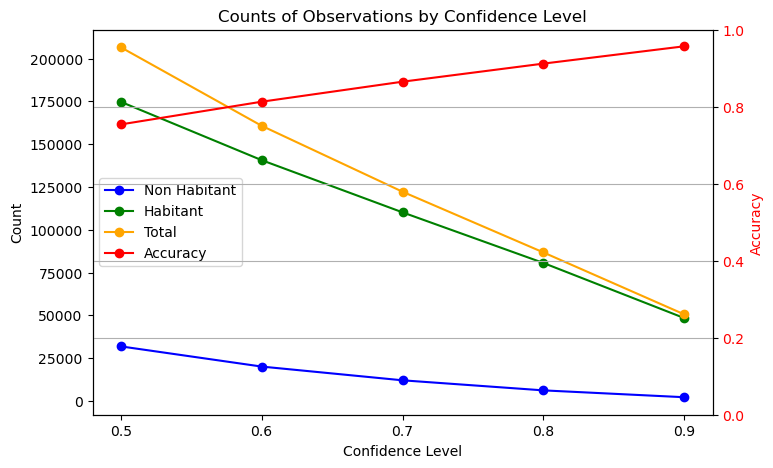

In [54]:
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Compute average accuracies for each dataset
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3)
]

# Extract counts for values 0 and 1 for each dataset
counts_0 = [x['Habitant'].value_counts().get(0, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
counts_1 = [x['Habitant'].value_counts().get(1, 0) for x in [data_05, data_06, data_07, data_08, data_09]]

# Compute total observation counts for each dataset
total_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Define x-axis positions for the confidence levels
x = range(len(datasets))

# Create the primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot counts on the primary y-axis
ax1.plot(x, counts_0, marker='o', linestyle='-', color='blue', label='Non Habitant')
ax1.plot(x, counts_1, marker='o', linestyle='-', color='green', label='Habitant')
ax1.plot(x, total_counts, marker='o', linestyle='-', color='orange', label='Total')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Count", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(x, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
ax2.set_ylabel("Accuracy", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)

# Set x-axis labels and plot title
plt.xticks(x, datasets)
plt.title("Counts of Observations by Confidence Level")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.grid(True)
plt.show()


In [55]:
# add up descriptions
print('Non Habitant Counts:')
print(counts_0)
print('Habitant Counts:')
print(counts_1)
print('Total Counts:')
print(total_counts)

Non Habitant Counts:
[31870, 20071, 12042, 6162, 2162]
Habitant Counts:
[174746, 140658, 110159, 80576, 48374]
Total Counts:
[206616, 160729, 122201, 86738, 50536]


Calculate absolute and relative differences between consecutive confidence levels

In [56]:
# Non Habitant
abs_0 = np.diff(counts_0) # Absolute difference
rel_0 = (np.diff(counts_0) / counts_0[:-1] * 100).round(2) # Relative differences: (current - previous) / previous * 100

print("Absolute differences, Non Habitant:", abs_0)
print("Relative differences (%), Non Habitant:", rel_0)

Absolute differences, Non Habitant: [-11799  -8029  -5880  -4000]
Relative differences (%), Non Habitant: [-37.02 -40.   -48.83 -64.91]


In [57]:
# Habitant
abs_1 = np.diff(counts_1)
rel_1 = (np.diff(counts_1) / counts_1[:-1] * 100).round(2)

print("Absolute differences, Habitant:", abs_1)
print("Relative differences (%), Habitant:", rel_1)

Absolute differences, Habitant: [-34088 -30499 -29583 -32202]
Relative differences (%), Habitant: [-19.51 -21.68 -26.85 -39.96]


In [58]:
# Total
abs_total = np.diff(total_counts)
rel_total = (np.diff(total_counts) / total_counts[:-1] * 100).round(2)

print("Absolute differences:", abs_total)
print("Relative differences (%):", rel_total)

Absolute differences: [-45887 -38528 -35463 -36202]
Relative differences (%): [-22.21 -23.97 -29.02 -41.74]


Plotting Counts and % Share of Habitant and Non Habitant Across Confidence Levels

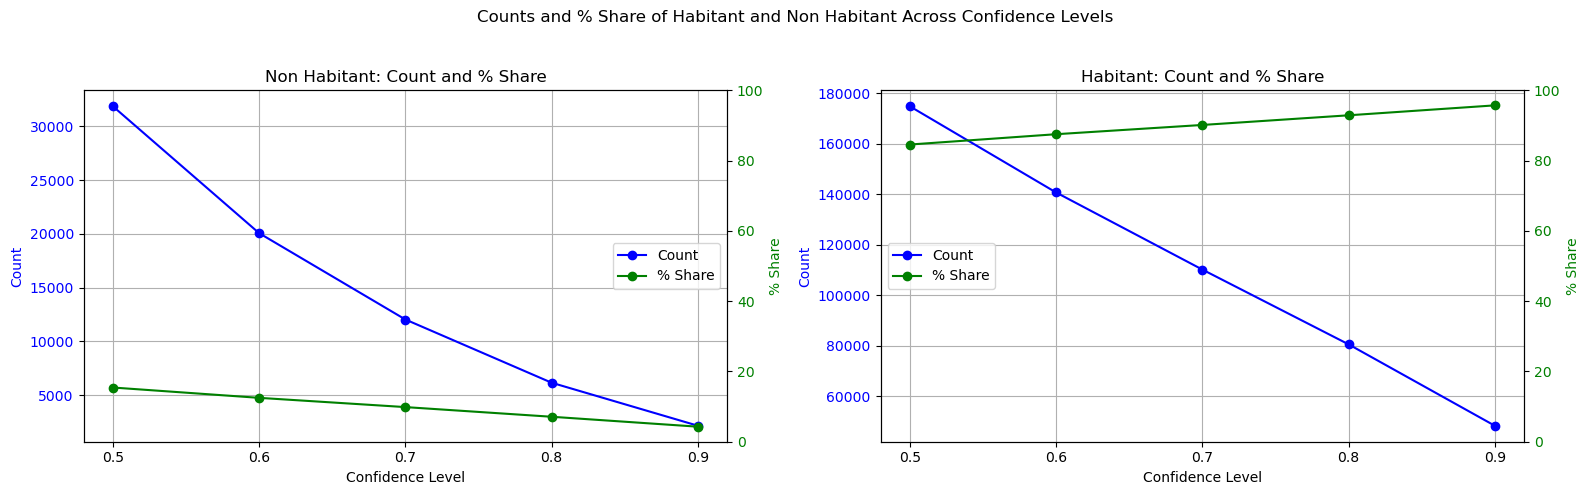

In [59]:
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']
x = range(len(datasets))

# Compute counts and percentages for Habitants 0 and 1
counts_0 = [x['Habitant'].value_counts().get(0, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
percentage_0 = [x['Habitant'].value_counts(normalize=True).get(0, 0) * 100 for x in [data_05, data_06, data_07, data_08, data_09]]

counts_1 = [x['Habitant'].value_counts().get(1, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
percentage_1 = [x['Habitant'].value_counts(normalize=True).get(1, 0) * 100 for x in [data_05, data_06, data_07, data_08, data_09]]

# Create a figure with two subplots side by side
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))

# Non Habitant
ax_left.plot(x, counts_0, marker='o', linestyle='-', color = 'blue', label='Count')
ax_left.set_xlabel("Confidence Level")
ax_left.set_ylabel("Count", color = 'blue')
ax_left.tick_params(axis='y', labelcolor='blue')
ax_left.set_xticks(x)
ax_left.set_xticklabels(datasets)
ax_left.grid(True)
ax_left.set_title("Non Habitant: Count and % Share")

# Create a twin y-axis for percentage on the left subplot
ax_left_twin = ax_left.twinx()
ax_left_twin.plot(x, percentage_0, marker='o', linestyle='-', color='green', label='% Share')
ax_left_twin.set_ylabel("% Share", color ='green')
ax_left_twin.tick_params(axis='y', labelcolor='green')
ax_left_twin.set_ylim(0, 100)

# Combine legends for the left subplot
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_left_twin, labels_left_twin = ax_left_twin.get_legend_handles_labels()
ax_left.legend(lines_left + lines_left_twin, labels_left + labels_left_twin, loc='center right')

# Habitant
ax_right.plot(x, counts_1, marker='o', linestyle='-', color = 'blue', label='Count')
ax_right.set_xlabel("Confidence Level")
ax_right.set_ylabel("Count", color = 'blue')
ax_right.tick_params(axis='y', labelcolor='blue')
ax_right.set_xticks(x)
ax_right.set_xticklabels(datasets)
ax_right.grid(True)
ax_right.set_title("Habitant: Count and % Share")

# Create a twin y-axis for percentage on the right subplot
ax_right_twin = ax_right.twinx()
ax_right_twin.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='% Share')
ax_right_twin.set_ylabel("% Share", color ='green')
ax_right_twin.tick_params(axis='y', labelcolor='green')
ax_right_twin.set_ylim(0, 100)

# Combine legends for the right subplot
lines_right, labels_right = ax_right.get_legend_handles_labels()
lines_right_twin, labels_right_twin = ax_right_twin.get_legend_handles_labels()
ax_right.legend(lines_right + lines_right_twin, labels_right + labels_right_twin, loc='center left')

# Add a main title and adjust layout
plt.suptitle("Counts and % Share of Habitant and Non Habitant Across Confidence Levels")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



Plotting Habitant and Non Habitant % Share and Total Accuracy Across Confidence Levels

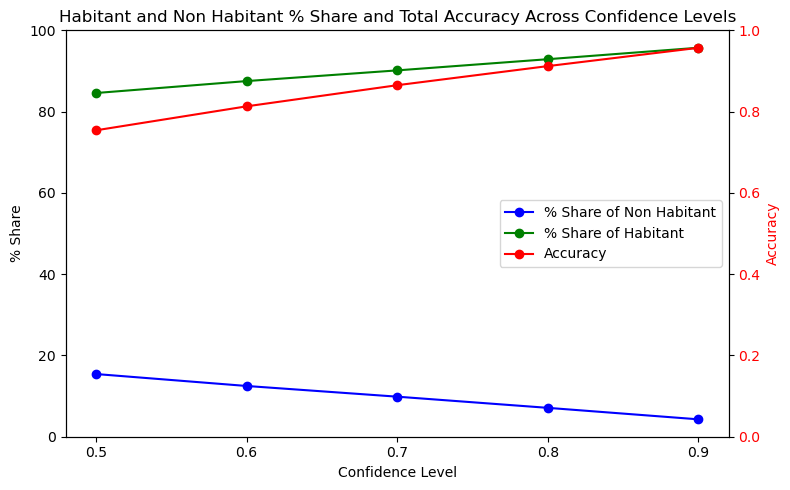

In [60]:
# Compute accuracies (mean of each 'Confidence') for each dataset
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3)
]

# Create one figure with twin y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))

# Primary axis: plot percentages for Habitant 0 and  1
line0, = ax1.plot(x, percentage_0, marker='o', linestyle='-', color='blue', label='% Share of Non Habitant')
line1, = ax1.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='% Share of Habitant')
ax1.set_xlabel("Confidence Level")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylabel("% Share", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 100)

# Secondary axis: plot Accuracy
ax2 = ax1.twinx()
line2, = ax2.plot(x, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
ax2.set_ylabel("Accuracy", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines = [line0, line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title("Habitant and Non Habitant % Share and Total Accuracy Across Confidence Levels")
plt.tight_layout()
plt.show()


In [61]:
print('Accuracy at Confidence 0.7: ', data_07['Confidence'].mean().round(3))
print(data_07['Habitant'].value_counts(normalize=True).round(2))


Accuracy at Confidence 0.7:  0.865
Habitant
1    0.9
0    0.1
Name: proportion, dtype: float64


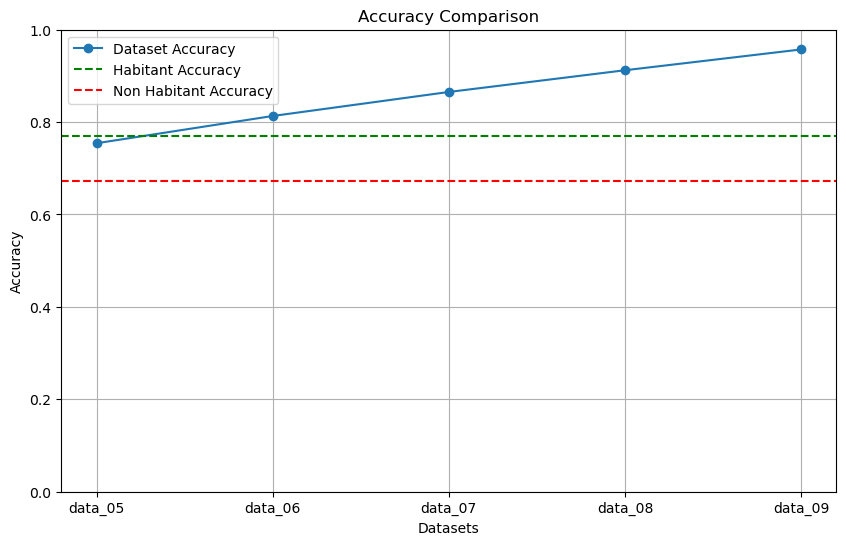

In [85]:
import matplotlib.pyplot as plt

# Calculate dataset accuracies
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3)
]

# Calculate overall habitant and non-habitant accuracies
accuracy_habitant = data[data['Habitant'] == 1]['Confidence'].mean().round(3)
accuracy_non_habitant = data[data['Habitant'] == 0]['Confidence'].mean().round(3)

# Create x-axis labels for the five datasets
datasets = ['data_05', 'data_06', 'data_07', 'data_08', 'data_09']
x = range(len(accuracies))

plt.figure(figsize=(10, 6))

# Plot the line chart for dataset accuracies
plt.plot(x, accuracies, marker='o', linestyle='-', label='Dataset Accuracy')

# Plot horizontal lines for habitant and non-habitant accuracies
plt.axhline(y=accuracy_habitant, color='green', linestyle='--', label='Habitant Accuracy')
plt.axhline(y=accuracy_non_habitant, color='red', linestyle='--', label='Non Habitant Accuracy')

plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.ylim(0, 1)  # Assuming accuracy values are between 0 and 1
plt.legend()
plt.grid(True)
plt.show()


In [63]:
accuracies

[0.754, 0.813, 0.865, 0.912, 0.957]

Total dataset accuracy is equal to % share of habitants at confidence level 0.7

Exploratory Data Analysis

In [64]:
df = data_07

In [65]:
df = df[df['Habitant'] == 1].reset_index(drop=True)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110159 entries, 0 to 110158
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Start (s)    110159 non-null  float64
 1   End (s)      110159 non-null  float64
 2   Common name  110159 non-null  object 
 3   Confidence   110159 non-null  float64
 4   ID           110159 non-null  object 
 5   Month        110159 non-null  int64  
 6   Day          110159 non-null  int64  
 7   Time         110159 non-null  int64  
 8   Latitude     110159 non-null  float64
 9   Longitude    110159 non-null  float64
 10  Elevation    110159 non-null  int64  
 11  Habitant     110159 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 10.1+ MB

First 10 rows:
   Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
0        6.0      9.0  hume's warbler      0.8799  psh10      6    4     6   
1       27.0     30.0  hume's warb

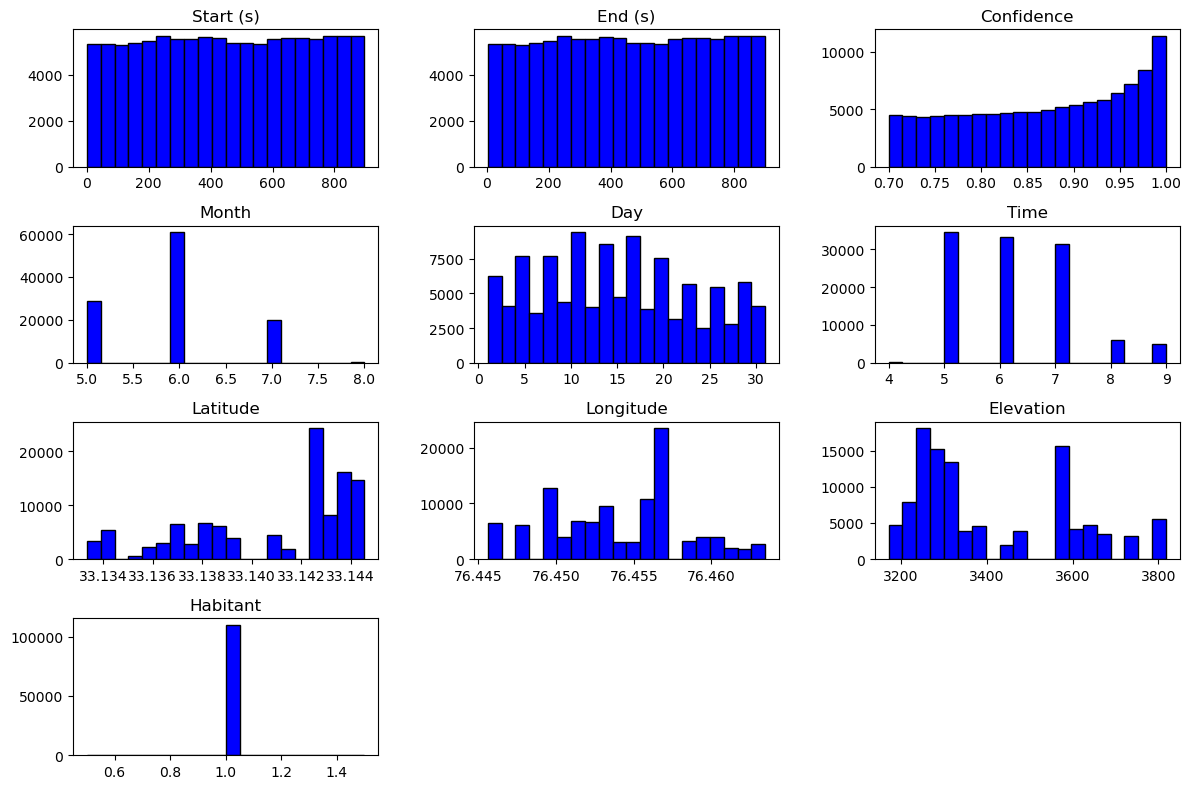

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


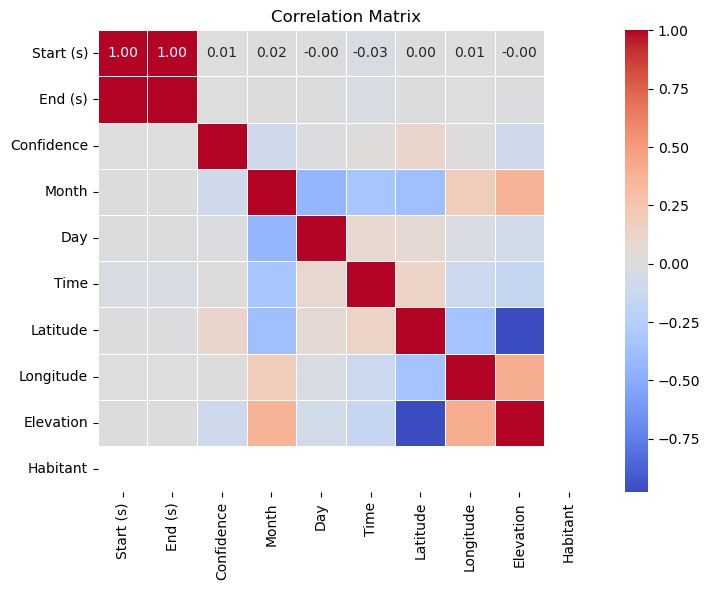


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant
0,6.0,9.0,hume's warbler,0.8799,psh10,6,4,6,33.135140,76.463139,3664,1
1,27.0,30.0,hume's warbler,0.8052,psh10,6,4,6,33.135140,76.463139,3664,1
2,39.0,42.0,hume's warbler,0.8985,psh10,6,4,6,33.135140,76.463139,3664,1
3,54.0,57.0,hume's warbler,0.7435,psh10,6,4,6,33.135140,76.463139,3664,1
4,60.0,63.0,hume's warbler,0.8016,psh10,6,4,6,33.135140,76.463139,3664,1
...,...,...,...,...,...,...,...,...,...,...,...,...
110154,54.0,57.0,variegated laughingthrush,0.8373,psm9,7,26,7,33.141258,76.461078,3438,1
110155,66.0,69.0,variegated laughingthrush,0.7415,psm9,7,26,7,33.141258,76.461078,3438,1
110156,72.0,75.0,variegated laughingthrush,0.8791,psm9,7,26,7,33.141258,76.461078,3438,1
110157,81.0,84.0,variegated laughingthrush,0.7492,psm9,7,26,7,33.141258,76.461078,3438,1


In [66]:
visual_data(df)

In [67]:
explore_dataset(df)

Column: Start (s)
Unique values:
[  6.  27.  39.  54.  60.  69.  75.  87.  93.  99. 123. 129. 135. 153.
 159. 165. 174. 180. 201. 213. 219. 225. 231. 240. 255. 261. 273. 282.
 288. 297. 300. 306. 321. 330. 351. 357. 378. 387. 411. 414. 456. 471.
 486. 501. 507. 516. 525. 534. 543. 546. 558. 561. 570. 573. 582. 597.
 606. 612. 615. 621. 627. 636. 642. 648. 663. 672. 681. 690. 699. 705.
 711. 720. 729. 738. 744. 753. 765. 774. 786. 795. 804. 813. 819. 828.
 837. 846. 855. 861. 867. 876.  12.  81. 234. 360. 492. 495. 594. 624.
 645. 657. 675. 696. 726. 762. 768. 777. 783. 789. 825. 831.  21.  45.
  48. 192. 198. 204. 285. 339. 429. 474. 510. 600. 885.  51. 150. 186.
 195. 216. 222. 228. 249. 276. 420. 423. 432. 603. 666. 171. 183. 189.
 210. 270. 366. 834. 849. 870. 879.  63.  84. 138. 156. 309. 489. 531.
 555. 147. 279. 342. 348. 369. 375. 435. 447. 462. 654. 660. 678. 723.
 759.  66. 639. 741.   9.  78. 111. 891. 702. 105. 108. 177. 264. 438.
 549. 567. 426. 498. 792. 801. 816. 873.  15

- Total Observations: 102,968
- 34 bird species were observed, with Western Crowned Warbler, Hume's Warbler, Variegated Laughingthrush, and Greenish Warbler making up nearly 82% of all the observations.
- Most common bird: Western Crowned Warbler (41.1% of all observations), followed by Hume's Warbler at 19.1%.
- Most observations occurred in June between 5 AM and 7 AM, at low elevations of 3200-3600 feet. The latitude ranged from 33.142 to 33.144, within 0.14 miles, and the longitude from 76.450 to 76.457, within 0.4 miles.

In [68]:
df_hume = df[df['Common name'] == "hume's warbler"]

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 18849 entries, 0 to 110153
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start (s)    18849 non-null  float64
 1   End (s)      18849 non-null  float64
 2   Common name  18849 non-null  object 
 3   Confidence   18849 non-null  float64
 4   ID           18849 non-null  object 
 5   Month        18849 non-null  int64  
 6   Day          18849 non-null  int64  
 7   Time         18849 non-null  int64  
 8   Latitude     18849 non-null  float64
 9   Longitude    18849 non-null  float64
 10  Elevation    18849 non-null  int64  
 11  Habitant     18849 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 1.9+ MB

First 10 rows:
   Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
0        6.0      9.0  hume's warbler      0.8799  psh10      6    4     6   
1       27.0     30.0  hume's warbler      0.8052  psh1

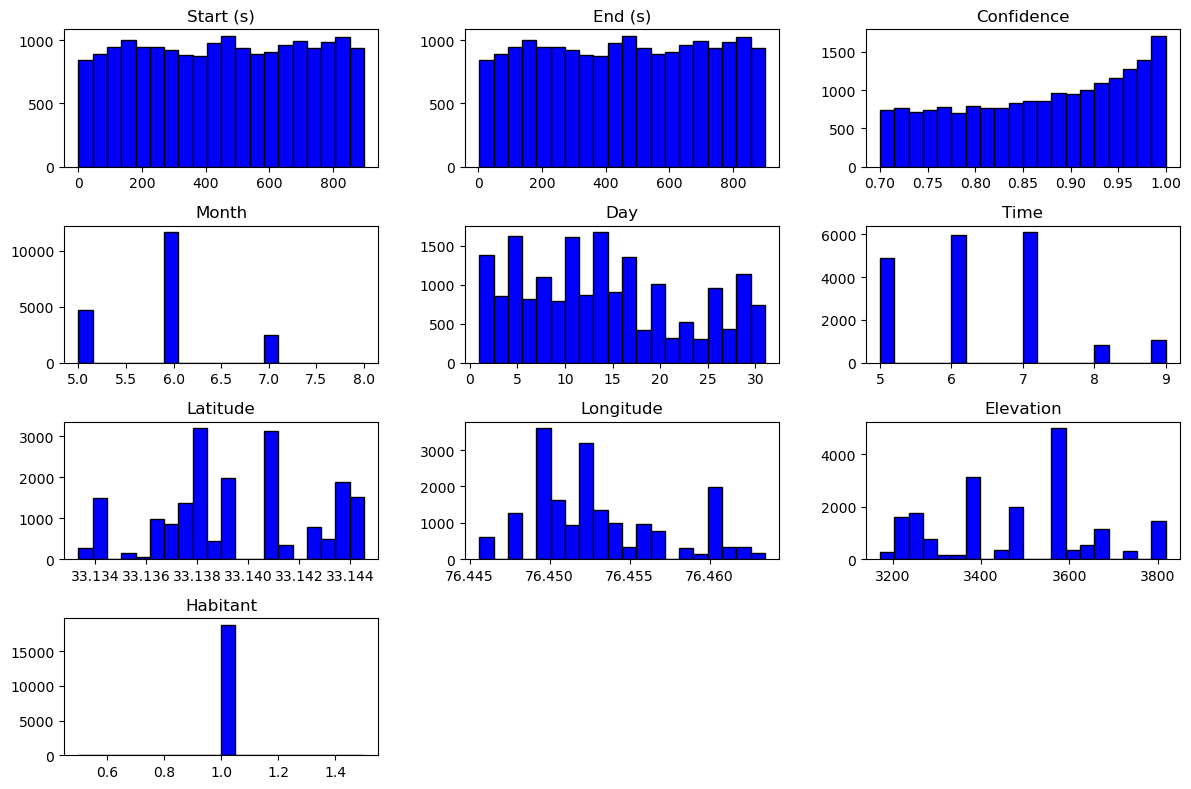

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


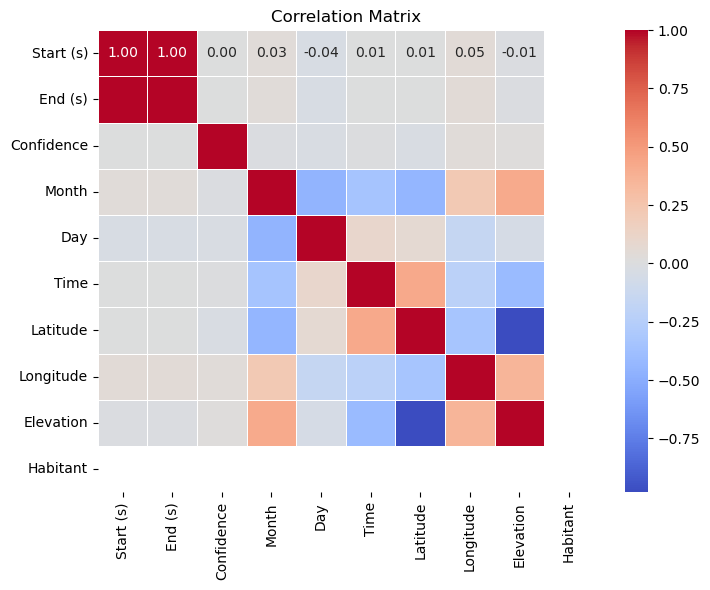


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant
0,6.0,9.0,hume's warbler,0.8799,psh10,6,4,6,33.135140,76.463139,3664,1
1,27.0,30.0,hume's warbler,0.8052,psh10,6,4,6,33.135140,76.463139,3664,1
2,39.0,42.0,hume's warbler,0.8985,psh10,6,4,6,33.135140,76.463139,3664,1
3,54.0,57.0,hume's warbler,0.7435,psh10,6,4,6,33.135140,76.463139,3664,1
4,60.0,63.0,hume's warbler,0.8016,psh10,6,4,6,33.135140,76.463139,3664,1
...,...,...,...,...,...,...,...,...,...,...,...,...
110063,177.0,180.0,hume's warbler,0.7831,psm9,7,20,6,33.141258,76.461078,3438,1
110099,507.0,510.0,hume's warbler,0.8413,psm9,7,24,6,33.141258,76.461078,3438,1
110119,48.0,51.0,hume's warbler,0.7175,psm9,7,25,6,33.141258,76.461078,3438,1
110120,99.0,102.0,hume's warbler,0.8946,psm9,7,25,6,33.141258,76.461078,3438,1


In [69]:
visual_data(df_hume)

In [70]:
explore_dataset(df_hume)

Column: Start (s)
Unique values:
[  6.  27.  39.  54.  60.  69.  75.  87.  93.  99. 123. 129. 135. 153.
 159. 165. 174. 180. 201. 213. 219. 225. 231. 240. 255. 261. 273. 282.
 288. 297. 300. 306. 321. 330. 351. 357. 486. 507. 534. 543. 546. 558.
 573. 582. 597. 606. 612. 615. 621. 627. 636. 642. 648. 663. 672. 681.
 690. 699. 705. 711. 720. 729. 738. 744. 753. 765. 774. 786. 795. 804.
 813. 819. 828. 837. 846. 855. 861. 867. 876.  81. 495. 594. 624. 645.
 657. 675. 696. 726. 762. 768. 777. 783. 789. 825. 831. 501. 342. 348.
 375. 378.  78. 111. 792. 801. 315. 327. 585.  84. 417. 435. 441. 444.
 447. 450. 453. 456. 459. 462. 465. 468. 474. 750. 156. 759. 183. 369.
 399. 414. 489. 513. 810. 822. 843. 849.  45. 426. 570. 603. 756. 780.
 138. 144. 147. 150. 258. 651. 660. 654. 714. 723. 732. 189. 264. 294.
 567. 633. 684. 834. 852. 873.  30. 192. 207. 216. 249. 291. 504. 618.
 702.  33.  42.  57. 108. 387. 492. 555. 564. 588. 591. 666. 747. 885.
 894.  15.  24. 114. 132. 162. 186. 198. 228

- Target specie is observed 19,697 times.
- Hume's Warbler is primarily observed at mid elevations, accounting for nearly 51% of all observations.
- It tends to sing most frequently between 6 AM and 7 AM, with slightly fewer observations at 5 AM.
- It is most commonly found at elevations between 3,475 and 3,650 feet, with a latitude range of 33.138 to 33.140 (within 0.14 miles) and a longitude range of 76.449 to 76.452 (within 0.17 miles).

Exploring the songs ( continuos intervals >= 3 sec of the same specie)

In [71]:
df_song = merge_contiguous_intervals(df)

In [72]:
df_song.to_csv('data/songs.csv')

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15959 entries, 0 to 15958
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Start (s)     15959 non-null  float64
 1   End (s)       15959 non-null  float64
 2   Common name   15959 non-null  object 
 3   Confidence    15959 non-null  float64
 4   ID            15959 non-null  object 
 5   Month         15959 non-null  int64  
 6   Day           15959 non-null  int64  
 7   Time          15959 non-null  int64  
 8   Latitude      15959 non-null  float64
 9   Longitude     15959 non-null  float64
 10  Elevation     15959 non-null  int64  
 11  Habitant      15959 non-null  int64  
 12  Duration (s)  15959 non-null  float64
dtypes: float64(6), int64(5), object(2)
memory usage: 1.6+ MB

First 10 rows:
   Start (s)  End (s)                Common name  Confidence     ID  Month  \
0      297.0    303.0             hume's warbler      0.7926  psh10     

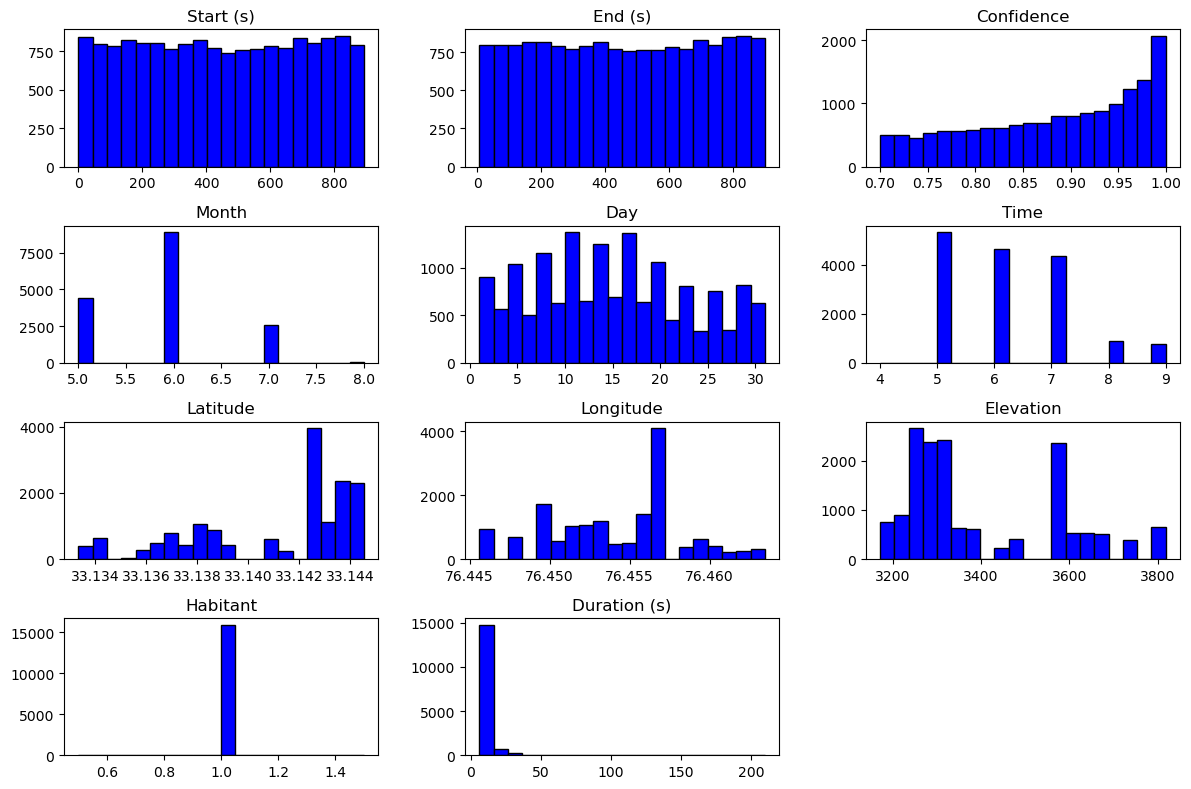

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


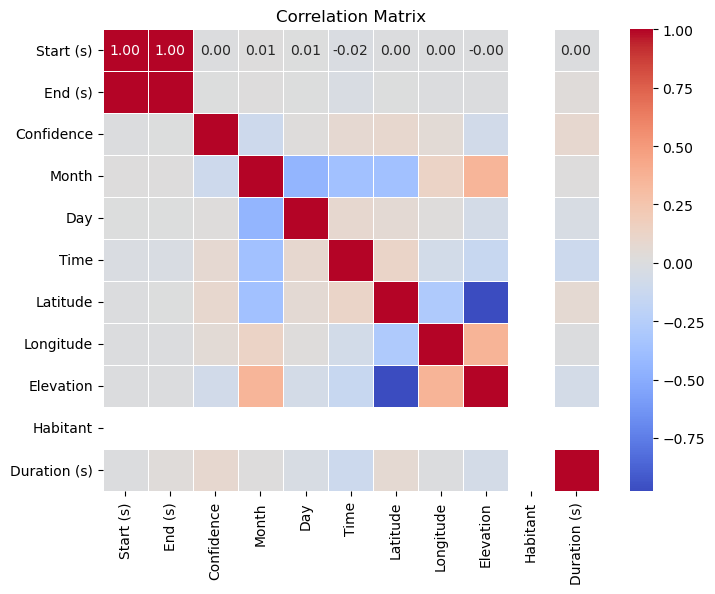


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Duration (s)
0,297.0,303.0,hume's warbler,0.7926,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
1,411.0,417.0,himalayan bluetail,0.8589,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
2,543.0,549.0,hume's warbler,0.8678,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
3,612.0,618.0,hume's warbler,0.7650,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
4,45.0,51.0,buff-barred warbler,0.7300,psh10,6,5,5,33.135140,76.463139,3664,1,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15954,660.0,672.0,variegated laughingthrush,0.8735,psm9,7,24,7,33.141258,76.461078,3438,1,12.0
15955,693.0,699.0,variegated laughingthrush,0.9726,psm9,7,24,7,33.141258,76.461078,3438,1,6.0
15956,102.0,108.0,himalayan bluetail,0.9987,psm9,7,25,7,33.141258,76.461078,3438,1,6.0
15957,135.0,141.0,himalayan bluetail,0.9670,psm9,7,25,7,33.141258,76.461078,3438,1,6.0


In [73]:
visual_data(df_song)

In [74]:
explore_dataset(df_song)

Column: Start (s)
Unique values:
[297. 411. 543. 612.  45. 192. 201. 213. 420.  81. 531. 375. 432. 621.
 720. 105.  42.  54. 204. 834. 882. 462. 501. 555. 570. 591. 609.  66.
 585. 789. 819. 129. 246. 345. 513. 228. 441. 813. 507.   6.  18.  27.
 669. 717. 759. 801.  12.  21.  51.  60.  69.  90.  99. 111. 120. 147.
 159. 231. 249. 267. 387.  75. 315. 753. 795. 843. 858.  15. 198. 402.
 414. 429. 438. 846. 876. 891. 477. 492. 525. 564. 588. 606. 639. 648.
 657. 666. 693. 714. 885.   9. 243. 336. 348. 357. 366. 378. 390. 408.
 600. 852.   3.  48.  78. 102. 138. 342. 633. 732. 210. 222. 417. 450.
 528. 567. 582. 645. 675. 711. 273. 300. 318. 456. 597. 186. 708. 726.
   0. 207. 240. 561. 618. 144. 699. 744. 261. 351. 255. 288. 294. 363.
 156. 180. 258. 651. 495. 540. 756. 783. 822.  84.  93. 594. 828. 135.
 177. 276. 678. 816. 168. 423. 459. 132. 141. 150. 165. 354. 393. 489.
 627. 660. 780. 855. 870. 468. 384. 396. 435. 444. 480. 576. 831. 183.
 723. 735. 486. 237.  33. 219.  24. 117. 360

In [75]:
df_champs = df_song[df_song['Duration (s)'] > 99]
df_champs

,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Duration (s)
2636,246.0,357.0,western crowned warbler,0.8150,psl10,5,30,5,33.143827,76.457181,3300,1,111.0
2639,531.0,681.0,western crowned warbler,0.9657,psl10,5,30,5,33.143827,76.457181,3300,1,150.0
2834,273.0,420.0,western crowned warbler,0.7326,psl10,6,3,5,33.143827,76.457181,3300,1,147.0
2897,129.0,237.0,western crowned warbler,0.9166,psl10,6,4,5,33.143827,76.457181,3300,1,108.0
2995,414.0,534.0,western crowned warbler,0.9766,psl10,6,6,5,33.143827,76.457181,3300,1,120.0
3038,444.0,573.0,western crowned warbler,0.9636,psl10,6,7,5,33.143827,76.457181,3300,1,129.0
3040,588.0,798.0,western crowned warbler,0.9580,psl10,6,7,5,33.143827,76.457181,3300,1,210.0
6753,249.0,351.0,western crowned warbler,0.9470,psl3,5,16,9,33.142799,76.452975,3289,1,102.0
7406,294.0,474.0,rufous-naped tit,0.9982,psl4,5,9,6,33.144064,76.451450,3242,1,180.0
8841,360.0,528.0,western crowned warbler,0.8564,psl5,6,8,5,33.143385,76.449970,3244,1,168.0


Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1360 entries, 2092 to 3761
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Start (s)     1360 non-null   float64
 1   End (s)       1360 non-null   float64
 2   Common name   1360 non-null   object 
 3   Confidence    1360 non-null   float64
 4   ID            1360 non-null   object 
 5   Month         1360 non-null   int64  
 6   Day           1360 non-null   int64  
 7   Time          1360 non-null   int64  
 8   Latitude      1360 non-null   float64
 9   Longitude     1360 non-null   float64
 10  Elevation     1360 non-null   int64  
 11  Habitant      1360 non-null   int64  
 12  Duration (s)  1360 non-null   float64
dtypes: float64(6), int64(5), object(2)
memory usage: 148.8+ KB

First 10 rows:
      Start (s)  End (s)              Common name  Confidence     ID  Month  \
2092      387.0    393.0  western crowned warbler      0.7871  psl10     

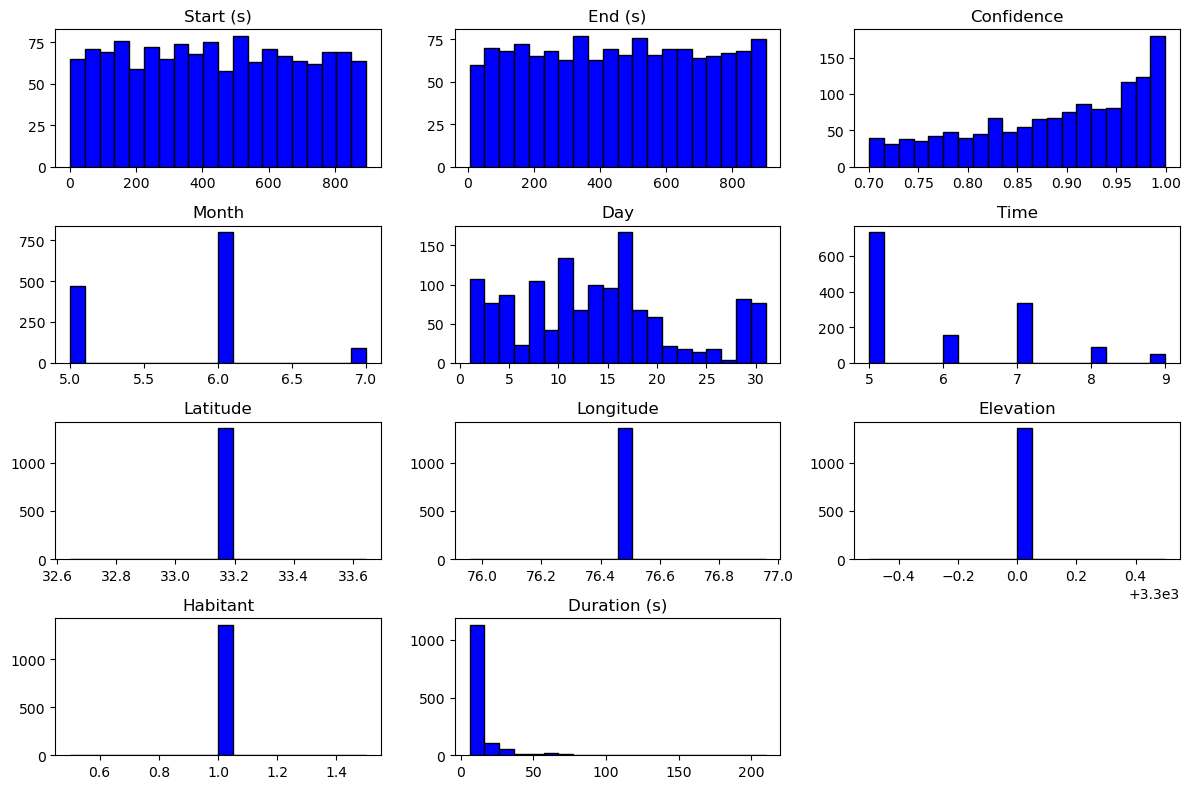

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


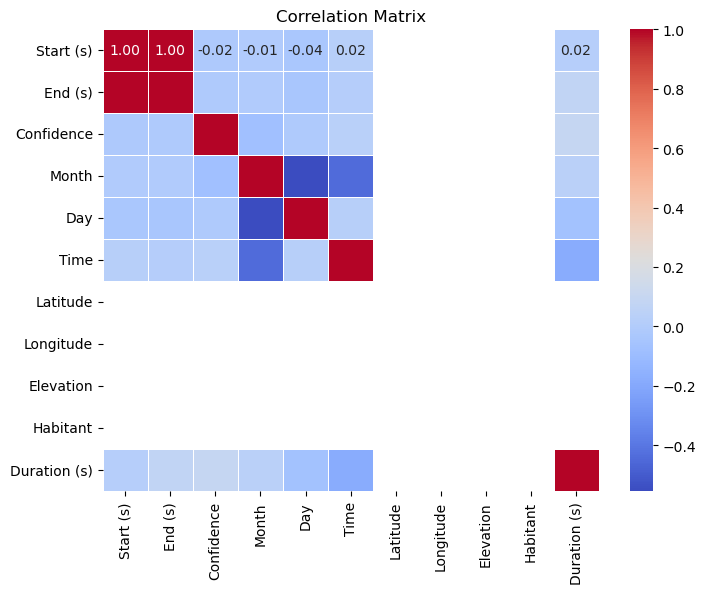


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Duration (s)
2092,387.0,393.0,western crowned warbler,0.7871,psl10,5,9,8,33.143827,76.457181,3300,1,6.0
2093,396.0,414.0,western crowned warbler,0.9309,psl10,5,9,8,33.143827,76.457181,3300,1,18.0
2094,0.0,42.0,western crowned warbler,0.9935,psl10,5,9,9,33.143827,76.457181,3300,1,42.0
2095,45.0,75.0,western crowned warbler,0.7085,psl10,5,9,9,33.143827,76.457181,3300,1,30.0
2096,81.0,87.0,western crowned warbler,0.8070,psl10,5,9,9,33.143827,76.457181,3300,1,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,741.0,747.0,western crowned warbler,0.8736,psl10,7,10,7,33.143827,76.457181,3300,1,6.0
3758,774.0,780.0,western crowned warbler,0.9519,psl10,7,10,7,33.143827,76.457181,3300,1,6.0
3759,783.0,789.0,western crowned warbler,0.8574,psl10,7,10,7,33.143827,76.457181,3300,1,6.0
3760,792.0,798.0,western crowned warbler,0.9812,psl10,7,10,7,33.143827,76.457181,3300,1,6.0


In [76]:
df_song_wcw = df_song[(df_song['Common name'] == "western crowned warbler") & (df_song['ID'] == 'psl10')]
visual_data(df_song_wcw)


In [77]:
df_song_hume = df_song[df_song['Common name'] == "hume's warbler"]

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 2561 entries, 0 to 15850
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Start (s)     2561 non-null   float64
 1   End (s)       2561 non-null   float64
 2   Common name   2561 non-null   object 
 3   Confidence    2561 non-null   float64
 4   ID            2561 non-null   object 
 5   Month         2561 non-null   int64  
 6   Day           2561 non-null   int64  
 7   Time          2561 non-null   int64  
 8   Latitude      2561 non-null   float64
 9   Longitude     2561 non-null   float64
 10  Elevation     2561 non-null   int64  
 11  Habitant      2561 non-null   int64  
 12  Duration (s)  2561 non-null   float64
dtypes: float64(6), int64(5), object(2)
memory usage: 280.1+ KB

First 10 rows:
     Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
0        297.0    303.0  hume's warbler      0.7926  psh10      6    4    

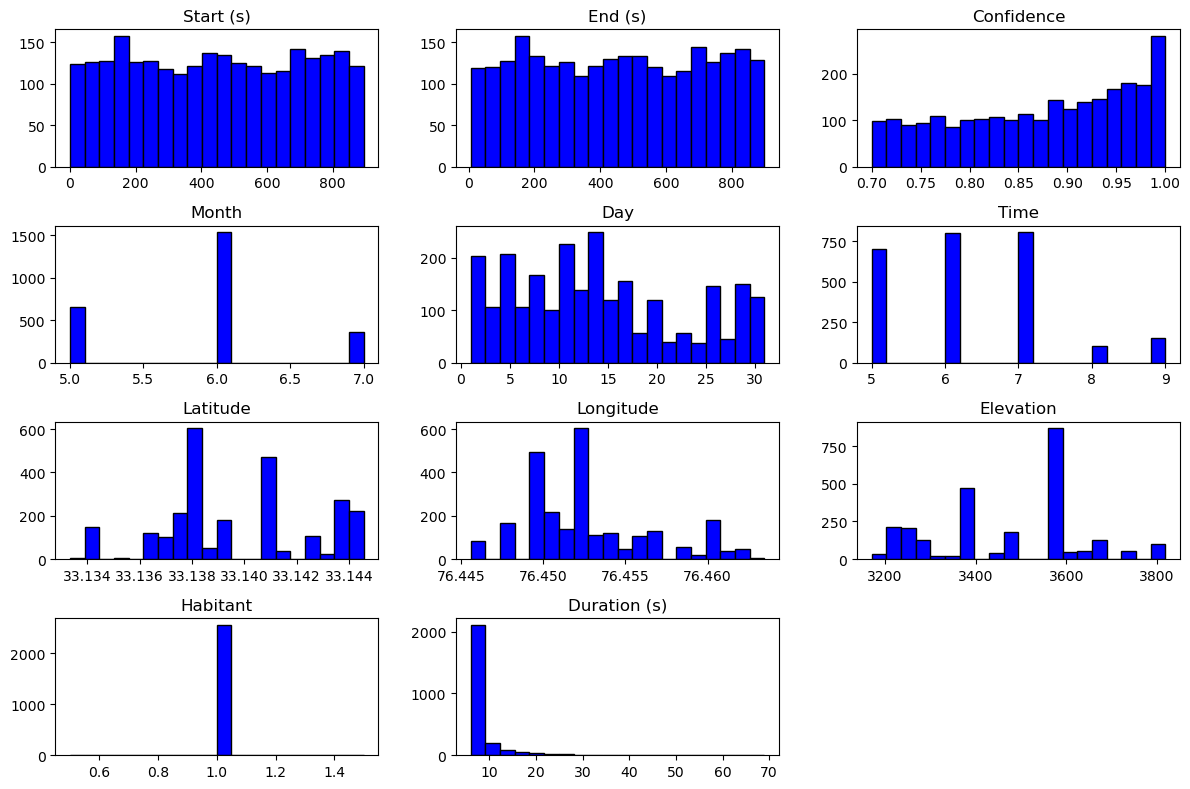

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


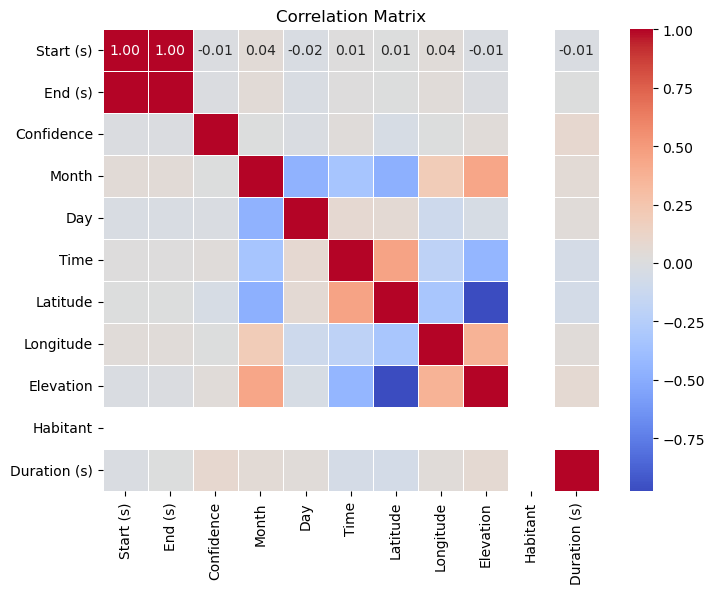


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Duration (s)
0,297.0,303.0,hume's warbler,0.7926,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
2,543.0,549.0,hume's warbler,0.8678,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
3,612.0,618.0,hume's warbler,0.7650,psh10,6,4,6,33.135140,76.463139,3664,1,6.0
11,375.0,381.0,hume's warbler,0.8918,psh10,6,6,6,33.135140,76.463139,3664,1,6.0
42,441.0,471.0,hume's warbler,0.8439,psh10,7,11,6,33.135140,76.463139,3664,1,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15846,705.0,714.0,hume's warbler,0.7448,psm9,6,18,6,33.141258,76.461078,3438,1,9.0
15847,717.0,735.0,hume's warbler,0.8033,psm9,6,18,6,33.141258,76.461078,3438,1,18.0
15848,750.0,756.0,hume's warbler,0.9343,psm9,6,18,6,33.141258,76.461078,3438,1,6.0
15849,789.0,795.0,hume's warbler,0.9303,psm9,6,18,6,33.141258,76.461078,3438,1,6.0


In [78]:
visual_data(df_song_hume)

In [79]:
explore_dataset(df_song_hume)   

Column: Start (s)
Unique values:
[297. 543. 612. 375. 441. 144. 588. 180. 258. 354. 378. 408. 417. 468.
  75. 102. 855. 360.  21. 321. 171. 480. 234. 516. 339. 159. 192. 510.
 519. 531. 585. 678. 690. 699. 708.  24. 117. 768. 777. 840. 177. 249.
 273. 156. 639. 426. 435. 552. 624. 651. 765. 783. 288. 330. 198. 210.
 675. 696.  90. 138. 201. 216. 228. 351. 366. 669. 705.  48.  57. 486.
 522. 864. 123. 252. 132. 570. 579. 363. 384. 744. 774. 789. 816. 873.
 300. 336. 342.  15. 165. 429. 489. 756. 786. 402. 462. 477. 114.  93.
  45. 153. 495. 195. 747.  87. 537. 561. 666. 885. 324.   0.  99. 444.
 501. 219. 246. 255. 282. 615. 657. 711. 726. 798. 225. 318. 513. 126.
 450. 648. 663. 717. 801. 237. 267. 753. 771. 222. 243. 432. 141.   3.
 852. 858. 186. 270. 291. 207. 645. 834. 843.  60. 240. 672. 633. 813.
 831. 525. 597. 681. 891. 459. 591. 279. 555. 567. 600. 660. 837.  84.
 759. 822. 888. 684. 750. 540. 546. 306. 492. 606. 807. 894. 390. 294.
  96. 792. 261. 405. 636.  36. 357. 780. 825

- A total of 15,432 observations were made where a bird was singing continuously for more than 3 seconds.
- The average duration of a continuous song is approximately 9 seconds.
- The "champion" for song duration is the Western Crowned Warbler, observed at low elevation.  
The longest songs were recorded at a specific location PSL10 with a latitude of 33.143827 and longitude of 76.457181, at an elevation of 3300 feet.  
This bird was observed at this spot 1,356 times (almost 9% of all bird observations), with 7 instances of singing for more than 108 seconds, reaching a maximum of 210 seconds (3.5 minutes).
- Hume's Warbler was observed 2,720 times (17.8% of total observations), with an average continuous song duration of 8.5 seconds, slightly below the overall average.
- 64% of its longer songs lasted 6 seconds, with a maximum duration of 69 seconds.
- Over 32% of Hume's Warbler's songs were recorded at elevations of 3570-3572 meters.

Explore who is signing 3 sec before and after Hume's Warbler

In [80]:
# df_birds_3 = birds_around(df)
# df_birds_3.to_csv('data/birds_around_3.csv')

In [81]:
df_birds_3 = pd.read_csv('data/birds_around_3.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'data/birds_around_3.csv'

In [ ]:
birds_3_before = df_birds_3[df_birds_3['Window'] == 'Before']
birds_3_after = df_birds_3[df_birds_3['Window'] == 'After']

In [ ]:
visual_data(birds_3_before)

In [ ]:
explore_dataset(birds_3_before)

In [ ]:
visual_data(birds_3_after)

In [ ]:
explore_dataset(birds_3_after)

Explore which birds are interacting within the same 3-second audio chunk

In [ ]:
df_group = filter_dataset_by_groups(df)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start (s)    1383 non-null   float64
 1   End (s)      1383 non-null   float64
 2   Common name  1383 non-null   object 
 3   Confidence   1383 non-null   float64
 4   ID           1383 non-null   object 
 5   Month        1383 non-null   int64  
 6   Day          1383 non-null   int64  
 7   Time         1383 non-null   int64  
 8   Latitude     1383 non-null   float64
 9   Longitude    1383 non-null   float64
 10  Elevation    1383 non-null   int64  
 11  Habitant     1383 non-null   int64  
 12  Temp_ID      1383 non-null   object 
dtypes: float64(5), int64(5), object(3)
memory usage: 140.6+ KB

First 10 rows:
   Start (s)  End (s)            Common name  Confidence     ID  Month  Day  \
0      357.0    360.0         hume's warbler      0.9889  psh10      6    4   
1      

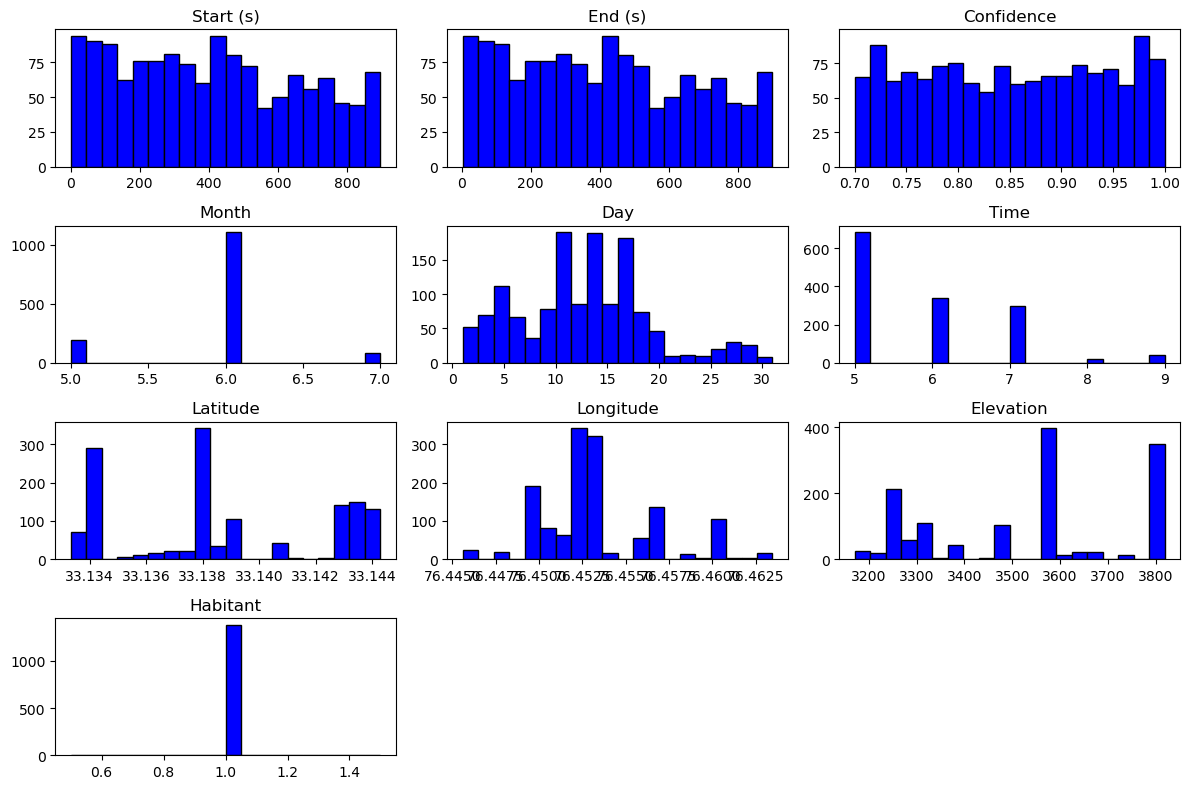

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


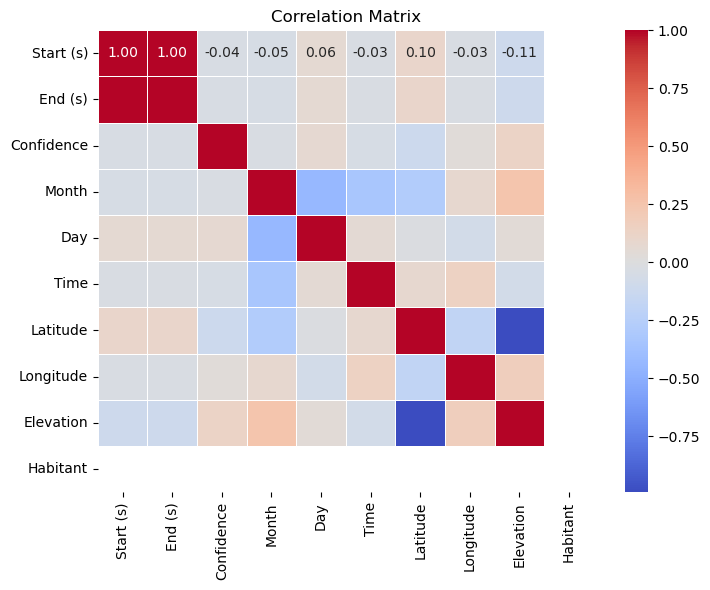


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.99


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Temp_ID
0,357.0,360.0,hume's warbler,0.9889,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
1,357.0,360.0,himalayan bluetail,0.7929,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
2,414.0,417.0,himalayan bluetail,0.9378,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
3,414.0,417.0,buff-barred warbler,0.8451,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
4,486.0,489.0,hume's warbler,0.9941,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_486.0_489.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,579.0,582.0,himalayan bluetail,0.7265,psm8,7,4,7,33.140866,76.449915,3370,1,psm8_7_4_7_579.0_582.0
1379,492.0,495.0,hume's warbler,0.8475,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1380,492.0,495.0,greenish warbler,0.7873,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1381,789.0,792.0,variegated laughingthrush,0.8647,psm9,6,2,7,33.141258,76.461078,3438,1,psm9_6_2_7_789.0_792.0


In [ ]:
visual_data(df_group) 

In [ ]:
explore_dataset(df_group)

Column: Start (s)
Unique values:
[357. 414. 486. 417. 591. 132.  48. 531. 876. 636. 264. 294.  30. 249.
 291. 513. 663. 201. 387. 492. 690. 729.  24.  84.  93. 153. 183. 198.
 231. 240. 267. 441. 510. 660. 156.  99. 684. 699. 720. 717. 114. 396.
 489. 576. 693. 456. 714.   3. 462. 681. 864. 411. 477. 870.  90. 186.
 270. 276. 288. 300. 303. 312. 363. 444. 450. 495.  54. 471. 117. 315.
 327. 339. 372. 384. 420. 429. 435. 549. 573. 858. 519.  18.  60.  81.
 324. 423. 594.  42. 120. 141. 483. 504. 543. 567. 585. 597.  36. 174.
 447. 453. 888. 330. 498. 507. 540. 603. 609. 807. 852. 873.  63. 831.
 837. 861.  15.  21.  33.  45.  57.  66.  72. 102. 147. 192. 219. 261.
 612. 669. 696. 894.  27. 879. 108. 207. 255. 765. 774. 732. 648. 702.
 783. 213. 225. 546. 360.  69. 438. 501. 642. 744. 762. 105. 780. 816.
 738. 234. 279. 246. 777. 756. 306. 522. 753. 285. 171. 723. 735. 237.
 348. 366. 402. 657. 228. 369. 135. 216. 336.  75.  39. 222. 252. 651.
 708. 129. 666. 828. 885. 891.  51.  78. 459

In [ ]:
df_group['Common name'].value_counts(normalize=True).round(2)*100   

Common name
hume's warbler                      32.0
himalayan bluetail                  25.0
western crowned warbler             13.0
variegated laughingthrush           10.0
tytler's leaf warbler                6.0
greenish warbler                     5.0
olive-backed pipit                   2.0
rufous-breasted accentor             1.0
himalayan monal                      1.0
common rosefinch                     1.0
slaty-blue flycatcher                1.0
buff-barred warbler                  1.0
large-billed leaf warbler            0.0
rock bunting                         0.0
himalayan white-browed rosefinch     0.0
eurasian kestrel                     0.0
blue-fronted redstart                0.0
tickell's leaf warbler               0.0
coal tit                             0.0
rufous-naped tit                     0.0
blue whistling-thrush                0.0
pink-browed rosefinch                0.0
eurasian wren                        0.0
Name: proportion, dtype: float64

In [ ]:
pairs = df_group.groupby('Temp_ID')['Common name'].apply(lambda x: tuple(sorted(x.unique())))


In [ ]:
pairs.value_counts()

Common name
(himalayan bluetail, hume's warbler)                      319
(tytler's leaf warbler, western crowned warbler)           82
(variegated laughingthrush, western crowned warbler)       73
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(olive-backed pipit, variegated laughingthrush)            21
(greenish warbler, himalayan bluetail)                     18
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(slaty-blue flycatcher, variegated laughingthrush)          4
(rock bunting, rufous-breasted accentor)                    4
(buff-barred warbler, himalayan bluetail)                   4
(eurasian kestrel, himalayan white-browed rosefinch)        4
(rufous-breasted accentor, variegated laughingthrush)       4
(hume's warbler, slaty-blue flycatcher)                   

In [ ]:
# Count the frequency of each unique pair
pair_counts = pairs.value_counts()
pairs_hume = pair_counts[[ "hume's warbler" in combo for combo in pair_counts.index ]] # Hume's warbler pairs
print(pairs_hume)

Common name
(himalayan bluetail, hume's warbler)                      319
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(hume's warbler, slaty-blue flycatcher)                     3
(hume's warbler, tickell's leaf warbler)                    3
(hume's warbler, large-billed leaf warbler)                 2
(buff-barred warbler, hume's warbler)                       2
(hume's warbler, pink-browed rosefinch)                     1
(greenish warbler, himalayan bluetail, hume's warbler)      1
Name: count, dtype: int64


- intercation- time correlation_ explore it within time change
- 